In [1]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
股票代码 = '601398'
start_date = "20240607"
end_date = '20250328'
threshold = 1.5
split_ratio = 0.7

In [3]:
source_data1 = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='')
data = pd.DataFrame()
data['date'] = source_data1['日期']
data['price1'] = source_data1['收盘']

In [4]:
配对股票代码 = '601288'

source_data2 = ak.stock_zh_a_hist(symbol=配对股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='')

data2 = pd.DataFrame()
data2['date'] = source_data2['日期']
data2['price2'] = source_data2['收盘']

data = pd.merge(data,data2,on='date')
data.set_index('date', inplace=True)
data.dropna()
data['return1'] = np.log(data['price1']/data['price1'].shift(1))
data['return2'] = np.log(data['price2']/data['price2'].shift(1))

In [59]:
data['price1'].corr(data['price2'])

0.9621305773094505

<Axes: xlabel='date'>

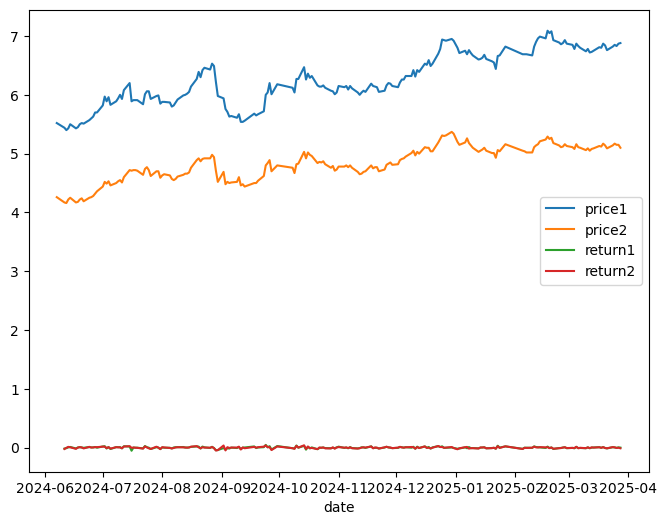

In [60]:
data.plot(figsize= (8,6))

In [61]:
data['spreed'] = abs(data['price1'] - data['price2'])

<Axes: xlabel='date'>

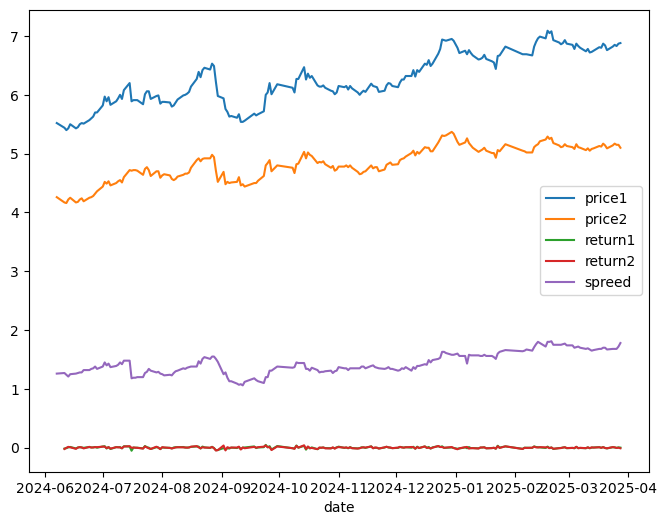

In [62]:
data.plot(figsize= (8,6))

In [63]:
data['zscore'] = (data['spreed'] - data['spreed'].mean()) / data['spreed'].std()

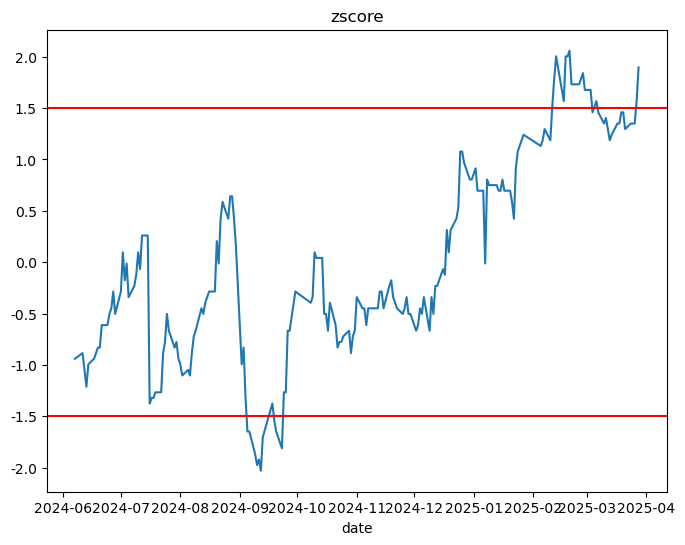

In [64]:
data['zscore'].plot (figsize= (8,6),title='zscore')
plt.axhline(threshold, color='red')
plt.axhline(-threshold, color='red')

In [65]:
data['position1']= np.where(data['zscore']>threshold ,1,np.nan)
data['position1']= np.where(data['zscore']<-threshold ,-1 ,data['position1'])
data['position1']= np.where(abs(data['zscore'])<0.5 ,0 ,data['position1'])
data['position1'] = data['position1'].fillna(0)
data['position2'] = -data['position1']

<Axes: title={'center': 'Stock1 Market Positioning'}, xlabel='date'>

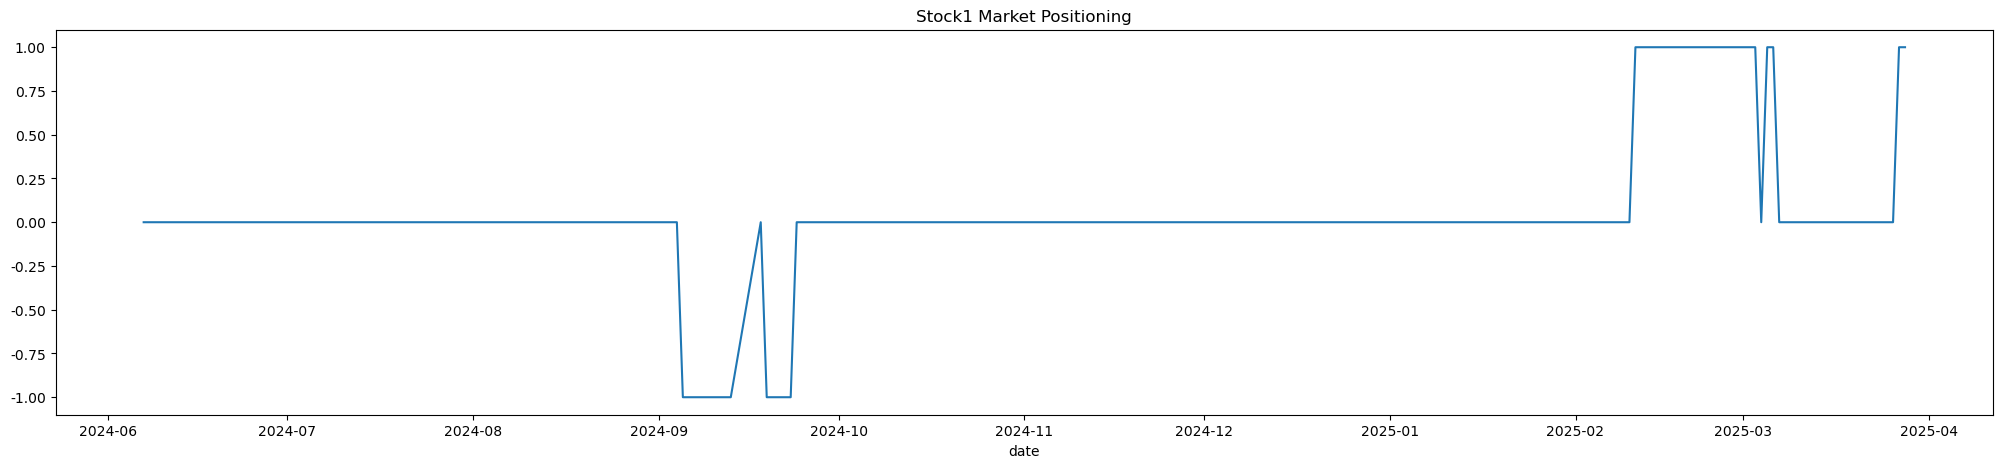

In [66]:
plt.rcParams['axes.unicode_minus'] = False # 显示负号
data['position1'].plot(ylim=[-1.1,1.1],figsize=(25,5),title='Stock1 Market Positioning')

<Axes: title={'center': 'Stock2 Market Positioning'}, xlabel='date'>

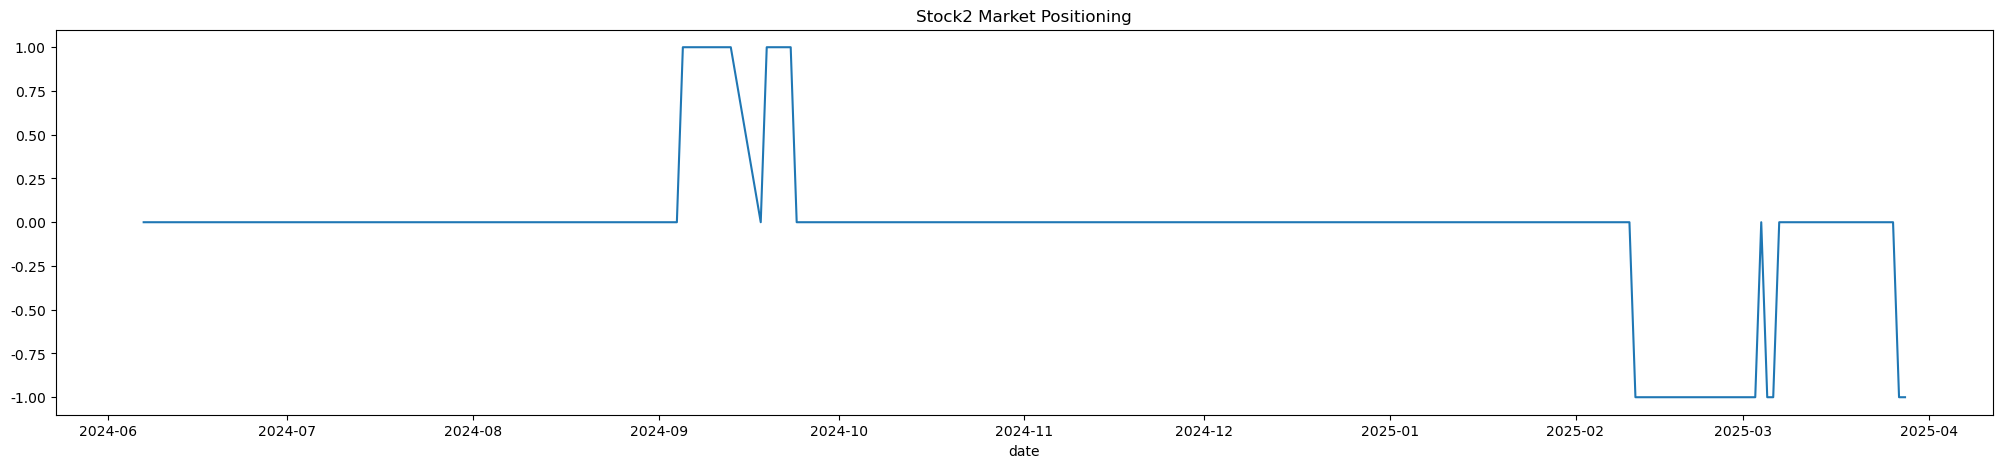

In [67]:
data['position2'].plot(ylim=[-1.1,1.1],figsize=(25,5),title='Stock2 Market Positioning')

In [68]:
data['strategy'] = data['position1'] * data['return1'].shift(1) + data['position2'] * data['return2'].shift(1)

<Axes: xlabel='date'>

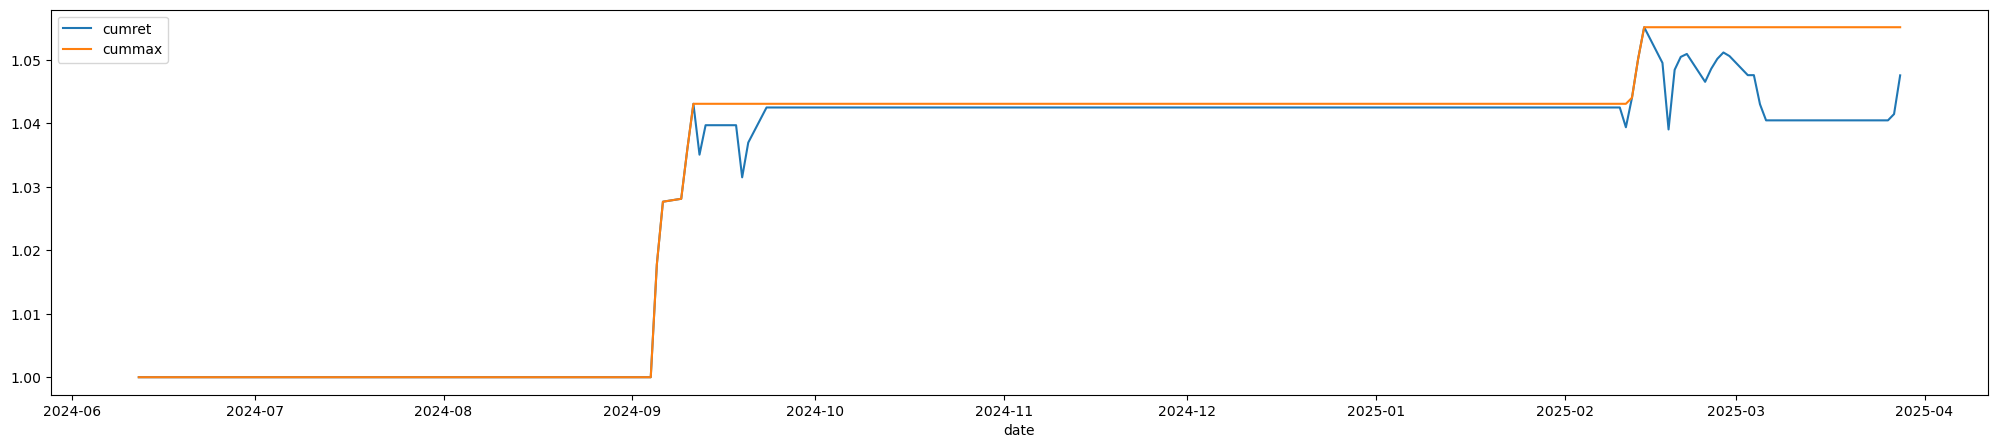

In [69]:
data['cumret'] = data['strategy'].cumsum().apply(np.exp)
data['cummax'] = data['cumret'].cummax()
data[['cumret','cummax']].plot(figsize=(25,5))

In [70]:
drawdown = (data['cummax'] - data['cumret'])/data['cummax']
drawdown.max()

0.015267175572519132